In [2]:
# %%
# ============================================================
# 📂 1. Load EVE Level-3 CSV (Corrected for notebook inside flare_data)
# ============================================================

import pandas as pd

file_path = "sdo_eve_ssi_1nm_l3 (2).csv"   # no folder prefix needed

# (optional safety: show file exists)
import os
if not os.path.exists(file_path):
    raise FileNotFoundError(f"❌ File not found at: {os.path.abspath(file_path)}")

df = pd.read_csv(file_path)

# Clean column names
df.columns = [c.strip().lower().replace(" ", "_")
              .replace("(", "").replace(")", "") for c in df.columns]

# Detect time column
time_col = [c for c in df.columns if "time" in c][0]
df["timestamp_utc"] = pd.to_datetime(df[time_col], errors="coerce")
df = df.dropna(subset=["timestamp_utc"])

# Filter for 6.5 nm wavelength
df = df[df["wavelength_nm"] == 6.5].copy()
df = df.rename(columns={"irradiance_w/m^2/nm": "irradiance_6p5nm"})
df = df[["timestamp_utc", "irradiance_6p5nm"]].reset_index(drop=True)

print("✅ Loaded EVE Level-3 6.5 nm irradiance file successfully!")
print("Total records:", len(df))
print(df.head(3))


✅ Loaded EVE Level-3 6.5 nm irradiance file successfully!
Total records: 5637
        timestamp_utc  irradiance_6p5nm
0 2010-04-30 12:00:34          0.000050
1 2010-05-01 12:00:34          0.000050
2 2010-05-02 12:00:34          0.000051


In [3]:
# %%
# ============================================================
# 🌞 2. DEFINE 10 FLARE START TIMES (UTC)
# ============================================================
# These are the start times for the 10 major flares
# You'll use them to extract EUV irradiance at T₀ / T₊1 / T₊2 days
# ============================================================

from datetime import datetime

flare_times = {
    "AR11158_M6.6": datetime(2011, 2, 13, 17, 28),
    "AR11158_X2.2": datetime(2011, 2, 15, 1, 44),
    "AR11261_M9.3": datetime(2011, 7, 30, 2, 4),
    "AR11429_X5.4": datetime(2012, 3, 7, 0, 2),
    "AR11429_M6.3": datetime(2012, 3, 9, 3, 22),
    "AR11520_X1.4": datetime(2012, 7, 12, 15, 37),
    "AR11719_M6.5": datetime(2013, 4, 11, 6, 55),
    "AR12036_M7.3": datetime(2014, 4, 18, 12, 31),
    "AR11944_X1.2": datetime(2014, 1, 7, 18, 4),
    "AR12017_X1.0": datetime(2014, 3, 29, 17, 35),
    "AR11166_X1.5":   datetime(2011, 3, 9, 23, 13),
    "AR11261_M6.0":   datetime(2011, 8, 3, 13, 17),
    "AR11261_M9.3b":  datetime(2011, 8, 4, 3, 41),
    "AR11283_M5.3":   datetime(2011, 9, 6, 1, 35),
    "AR11283_X2.1":   datetime(2011, 9, 6, 22, 12),
    "AR11283_X1.8":   datetime(2011, 9, 7, 22, 32),
    "AR11283_M6.7":   datetime(2011, 9, 8, 15, 32),
    "AR11302_M7.4":   datetime(2011, 9, 25, 4, 31),
    "AR11402_M8.7":   datetime(2012, 1, 23, 3, 38),
    "AR11429_X1.3":   datetime(2012, 3, 7, 1, 5),
    "AR11429_M8.4":   datetime(2012, 3, 10, 17, 15),
    "AR11476_M5.7":   datetime(2012, 5, 10, 4, 11),
    "AR11515_M5.6":   datetime(2012, 7, 2, 10, 43),
    "AR11515_M5.3":   datetime(2012, 7, 4, 9, 47),
    "AR11515_M6.1":   datetime(2012, 7, 5, 11, 39),
    "AR11877_M9.3":   datetime(2013, 10, 24, 0, 21),
    "AR11884_M6.3":   datetime(2013, 11, 1, 19, 46),
    "AR11884_M5.0":   datetime(2013, 11, 3, 5, 16),
    "AR11890_X1.1a":  datetime(2013, 11, 8, 4, 20),
    "AR11890_X1.1b":  datetime(2013, 11, 10, 5, 8),
    "AR11936_M6.4":   datetime(2013, 12, 31, 21, 45),
    "AR11944_M7.2":   datetime(2014, 1, 7, 10, 7),
    "AR12035_X1.3":   datetime(2014, 4, 25, 0, 17),
}

print("✅ Defined flare start times:")
for flare, t in flare_times.items():
    print(f"   {flare:15s} → {t}")


✅ Defined flare start times:
   AR11158_M6.6    → 2011-02-13 17:28:00
   AR11158_X2.2    → 2011-02-15 01:44:00
   AR11261_M9.3    → 2011-07-30 02:04:00
   AR11429_X5.4    → 2012-03-07 00:02:00
   AR11429_M6.3    → 2012-03-09 03:22:00
   AR11520_X1.4    → 2012-07-12 15:37:00
   AR11719_M6.5    → 2013-04-11 06:55:00
   AR12036_M7.3    → 2014-04-18 12:31:00
   AR11944_X1.2    → 2014-01-07 18:04:00
   AR12017_X1.0    → 2014-03-29 17:35:00
   AR11166_X1.5    → 2011-03-09 23:13:00
   AR11261_M6.0    → 2011-08-03 13:17:00
   AR11261_M9.3b   → 2011-08-04 03:41:00
   AR11283_M5.3    → 2011-09-06 01:35:00
   AR11283_X2.1    → 2011-09-06 22:12:00
   AR11283_X1.8    → 2011-09-07 22:32:00
   AR11283_M6.7    → 2011-09-08 15:32:00
   AR11302_M7.4    → 2011-09-25 04:31:00
   AR11402_M8.7    → 2012-01-23 03:38:00
   AR11429_X1.3    → 2012-03-07 01:05:00
   AR11429_M8.4    → 2012-03-10 17:15:00
   AR11476_M5.7    → 2012-05-10 04:11:00
   AR11515_M5.6    → 2012-07-02 10:43:00
   AR11515_M5.3    → 2012-07

In [4]:
# %%
# ============================================================
# 🧮 3. BUILD 3-DAY EUV IRRADIANCE TARGET TABLE
# ============================================================
# For each flare:
#   • Find nearest EVE record at T₀, T₊1, T₊2 days
#   • Save results into a new CSV
# ============================================================

from datetime import timedelta
import pandas as pd

def nearest_irradiance(df_eve, target_time):
    """Return nearest EVE 6.5 nm irradiance value for a given UTC time."""
    idx = (df_eve["timestamp_utc"] - target_time).abs().idxmin()
    return df_eve.loc[idx, "irradiance_6p5nm"]

records = []
for flare, t0 in flare_times.items():
    vals = []
    for i in range(3):   # T₀, T₊1, T₊2
        t = t0 + timedelta(days=i)
        val = nearest_irradiance(df, t)
        vals.append(val)
    records.append((flare, t0, *vals))

target_df = pd.DataFrame(
    records,
    columns=["flare_id", "flare_time", "EUV_T0", "EUV_T1", "EUV_T2"]
)

# Save to CSV
out_csv = "flare_euv_targets_3day.csv"
target_df.to_csv(out_csv, index=False)

print(f"💾 Saved → {out_csv}")
display(target_df)


💾 Saved → flare_euv_targets_3day.csv


,flare_id,flare_time,EUV_T0,EUV_T1,EUV_T2
0,AR11158_M6.6,2011-02-13 17:28:00,0.000060,0.000062,0.000063
1,AR11158_X2.2,2011-02-15 01:44:00,0.000063,0.000062,0.000064
2,AR11261_M9.3,2011-07-30 02:04:00,0.000062,0.000064,0.000067
3,AR11429_X5.4,2012-03-07 00:02:00,0.000084,0.000080,0.000083
4,AR11429_M6.3,2012-03-09 03:22:00,0.000083,0.000085,0.000081
5,AR11520_X1.4,2012-07-12 15:37:00,0.000086,0.000080,0.000080
6,AR11719_M6.5,2013-04-11 06:55:00,0.000097,0.000095,0.000090
7,AR12036_M7.3,2014-04-18 12:31:00,0.000113,0.000113,0.000114
8,AR11944_X1.2,2014-01-07 18:04:00,0.000113,0.000108,0.000107
9,AR12017_X1.0,2014-03-29 17:35:00,0.000119,0.000120,0.000121


✅ Loaded /Users/sathviksoman/Downloads/Surya/downstream_examples/euv_spectra_prediction/assets/flare_data/AR11158_M6.6/full_disk/npz_hmi/20110212T1658.npz
Available channels: ['hmiB_azim', 'hmiB_field', 'hmiB_incl', 'hmiIC', 'hmiM']


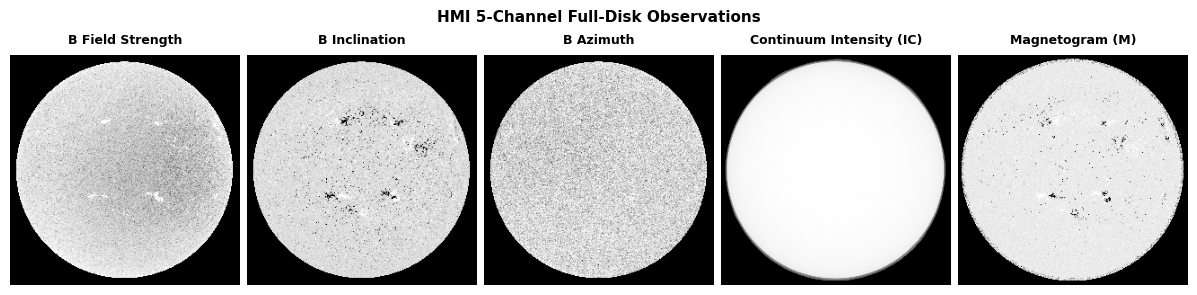

In [5]:
# %%
# ============================================================
# ☀️ HMI 5-CHANNEL FULL-DISK OBSERVATIONS (IEEE FINAL, North-Up)
# ============================================================
# • Shows all 5 HMI products (B_field, B_incl, B_azim, IC, M)
# • Corrects orientation (flip vertically → solar north up)
# • Smart normalization (1st–99th percentile stretch)
# • Balanced IEEE layout, bold titles, black background
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import os

# --- Path to NPZ file (update if needed) ---
npz_path = "/Users/sathviksoman/Downloads/Surya/downstream_examples/euv_spectra_prediction/assets/flare_data/AR11158_M6.6/full_disk/npz_hmi/20110212T1658.npz"
if not os.path.exists(npz_path):
    raise FileNotFoundError(f"❌ File not found: {npz_path}")

data = np.load(npz_path)
print(f"✅ Loaded {npz_path}")
print("Available channels:", list(data.keys()))

# --- Smart normalization with explicit vertical flip ---
def smart_display(frame):
    """Normalize frame to [0,1] using 1–99 percentile and flip vertically."""
    f = np.nan_to_num(frame)
    lo, hi = np.percentile(f, 1), np.percentile(f, 99)
    f = np.clip(f, lo, hi)
    f = (f - lo) / (hi - lo + 1e-6)
    return np.flipud(f)  # <-- flip image vertically (north up)

# --- Channel mapping ---
channels = ["hmiB_field", "hmiB_incl", "hmiB_azim", "hmiIC", "hmiM"]
titles = [
    "B Field Strength",
    "B Inclination",
    "B Azimuth",
    "Continuum Intensity (IC)",
    "Magnetogram (M)",
]

# --- IEEE figure layout ---
plt.figure(figsize=(12, 3.0))  # fits single-column width

for i, ch in enumerate(channels):
    if ch not in data:
        continue
    arr = data[ch]
    mid = arr.shape[0] // 2
    frame = smart_display(arr[mid])   # ✅ apply flip + normalization

    plt.subplot(1, len(channels), i + 1)
    plt.imshow(frame, cmap="gray", origin="lower")
    plt.title(titles[i], fontsize=9, fontweight="bold", pad=8)
    plt.axis("off")
    plt.gca().set_facecolor("black")  # black margin background

plt.suptitle("HMI 5-Channel Full-Disk Observations",
             fontsize=11, fontweight="bold", y=0.99)
plt.tight_layout(pad=0.8, w_pad=0.5)
plt.savefig("fig_hmi_5channel_final_northup.pdf", bbox_inches="tight", dpi=600)
plt.show()


✅ Loaded /Users/sathviksoman/Downloads/Surya/downstream_examples/euv_spectra_prediction/assets/flare_data/AR11158_M6.6/full_disk/npz_aia/20110212T1728.npz
Available channels: ['aia335', 'aia131', 'aia304', 'aia1600', 'aia193', 'aia211', 'aia171', 'aia94']


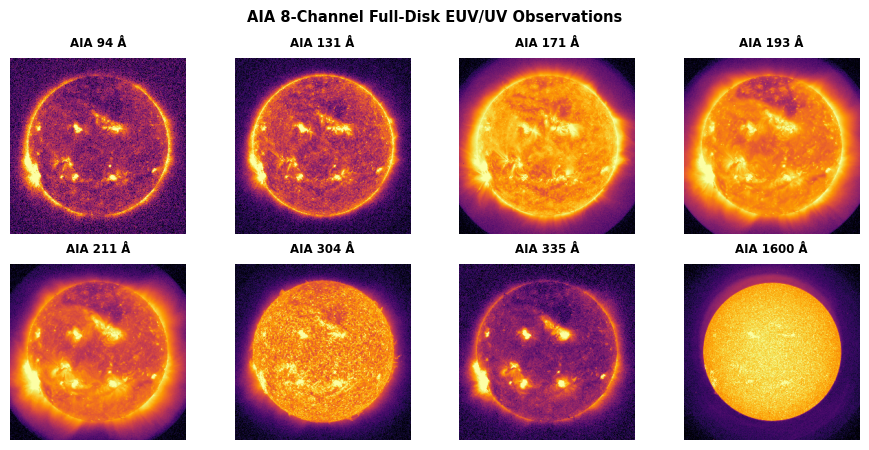

In [6]:
# %%
# ============================================================
# ☀️ AIA 8-CHANNEL FULL-DISK (IEEE Style, Final Spacing Tuned)
# ============================================================
# • Inferno colormap (scientific AIA standard)
# • Solar north-up (flip vertically)
# • Balanced IEEE layout
# • Small extra gap between top and bottom rows (no image shrink)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import os

# --- Path to AIA NPZ file ---
npz_path = "/Users/sathviksoman/Downloads/Surya/downstream_examples/euv_spectra_prediction/assets/flare_data/AR11158_M6.6/full_disk/npz_aia/20110212T1728.npz"
if not os.path.exists(npz_path):
    raise FileNotFoundError(f"❌ File not found: {npz_path}")

data = np.load(npz_path)
print(f"✅ Loaded {npz_path}")
print("Available channels:", list(data.keys()))

# --- Smart normalization (1–99%) + solar north-up orientation ---
def smart_display(frame):
    f = np.nan_to_num(frame)
    lo, hi = np.percentile(f, 1), np.percentile(f, 99)
    f = np.clip(f, lo, hi)
    f = (f - lo) / (hi - lo + 1e-6)
    return np.flipud(f)

# --- AIA wavelength channels and labels ---
channels = ["aia94", "aia131", "aia171", "aia193", "aia211", "aia304", "aia335", "aia1600"]
titles = [
    "AIA 94 Å", "AIA 131 Å", "AIA 171 Å", "AIA 193 Å",
    "AIA 211 Å", "AIA 304 Å", "AIA 335 Å", "AIA 1600 Å"
]

available = [ch for ch in channels if ch in data]
n = len(available)

# --- IEEE grid: 2×4, same full-size disks ---
cols = 4
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(9.0, 4.6))
axes = np.array(axes).reshape(-1)

for i, ch in enumerate(available):
    arr = data[ch]
    mid = arr.shape[0] // 2
    frame = smart_display(arr[mid])
    ax = axes[i]
    ax.imshow(frame, cmap="inferno", origin="lower")
    ax.set_title(titles[i], fontsize=8.5, fontweight="bold", pad=8)  # +1px pad for row title spacing
    ax.axis("off")
    ax.set_facecolor("black")

# Hide unused subplots if fewer than 8
for ax in axes[len(available):]:
    ax.remove()

# --- Adjust spacing (extra gap between rows only) ---
plt.suptitle("AIA 8-Channel Full-Disk EUV/UV Observations",
             fontsize=10.5, fontweight="bold", y=0.985)
plt.subplots_adjust(left=0.02, right=0.98, top=0.88, bottom=0.05,
                    wspace=0.18, hspace=0.17)  # ⬅️ slightly larger vertical spacing

# --- Save IEEE-ready figure ---
plt.savefig("fig_aia_8channel_inferno_ieee_final.pdf", bbox_inches="tight", dpi=600)
plt.show()


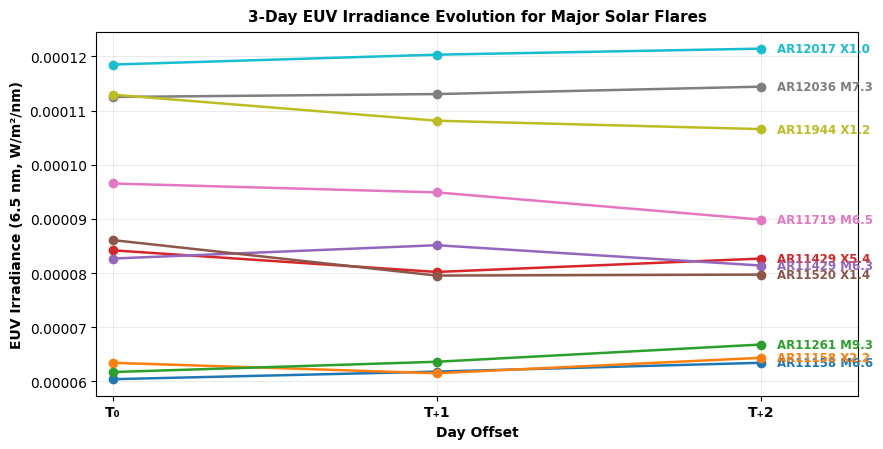

In [2]:
# %%
# ============================================================
# 📈 FIG. — 3-Day EUV Irradiance Evolution (T₀ → T₊₂)
# ============================================================

import pandas as pd, matplotlib.pyplot as plt, numpy as np

df = pd.read_csv("flare_euv_targets_3day.csv")
x = np.array([0, 1, 2])

plt.figure(figsize=(9, 4.6))
colors = plt.cm.tab10.colors

for i, (_, r) in enumerate(df.iterrows()):
    y = [r.EUV_T0, r.EUV_T1, r.EUV_T2]
    c = colors[i % len(colors)]
    plt.plot(x, y, marker="o", linewidth=1.8, color=c)
    plt.text(2.05, y[-1], r.flare_id.replace("_"," "),
             color=c, fontsize=8.5, weight="semibold", va="center", ha="left")

plt.xlim(-0.05, 2.3)
plt.xticks(x, ["T₀", "T₊1", "T₊2"], fontsize=10, weight="semibold")
plt.xlabel("Day Offset", fontsize=10, weight="semibold")
plt.ylabel("EUV Irradiance (6.5 nm, W/m²/nm)", fontsize=10, weight="semibold")
plt.title("3-Day EUV Irradiance Evolution for Major Solar Flares",
          fontsize=11, weight="bold", pad=8)
plt.grid(alpha=0.3, lw=0.6)
plt.tight_layout()

plt.savefig("fig_euv_3day_evolution.pdf", bbox_inches="tight", dpi=600)
plt.show()


/var/folders/pk/m7lfxd2971g41xbphqgw0r1m0000gn/T/ipykernel_68931/1528223151.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df.EUV_T0, df.EUV_T1, df.EUV_T2],


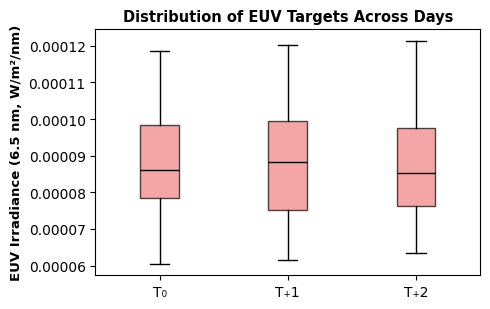

In [7]:
# %%
# ============================================================
# 📦 FIG. — Distribution of EUV Targets Across T₀–T₊₂
# ============================================================

import matplotlib.pyplot as plt, pandas as pd

df = pd.read_csv("flare_euv_targets_3day.csv")

plt.figure(figsize=(5,3.2))
plt.boxplot([df.EUV_T0, df.EUV_T1, df.EUV_T2],
            labels=["T₀", "T₊1", "T₊2"],
            patch_artist=True,
            boxprops=dict(facecolor='lightcoral', alpha=0.7),
            medianprops=dict(color='black'))
plt.ylabel("EUV Irradiance (6.5 nm, W/m²/nm)", fontsize=9.5, weight="semibold")
plt.title("Distribution of EUV Targets Across Days", fontsize=10.5, weight="bold")
plt.tight_layout()
plt.savefig("fig_euv_boxplot.pdf", bbox_inches="tight", dpi=600)
plt.show()


✅ Loaded 33 flares from CSV
📊 Plotting decay ratios for 33 flares
✅ Saved: figures/12fig_relative_decay_heatmap.pdf
✅ Saved: figures/12fig_relative_decay_heatmap.png


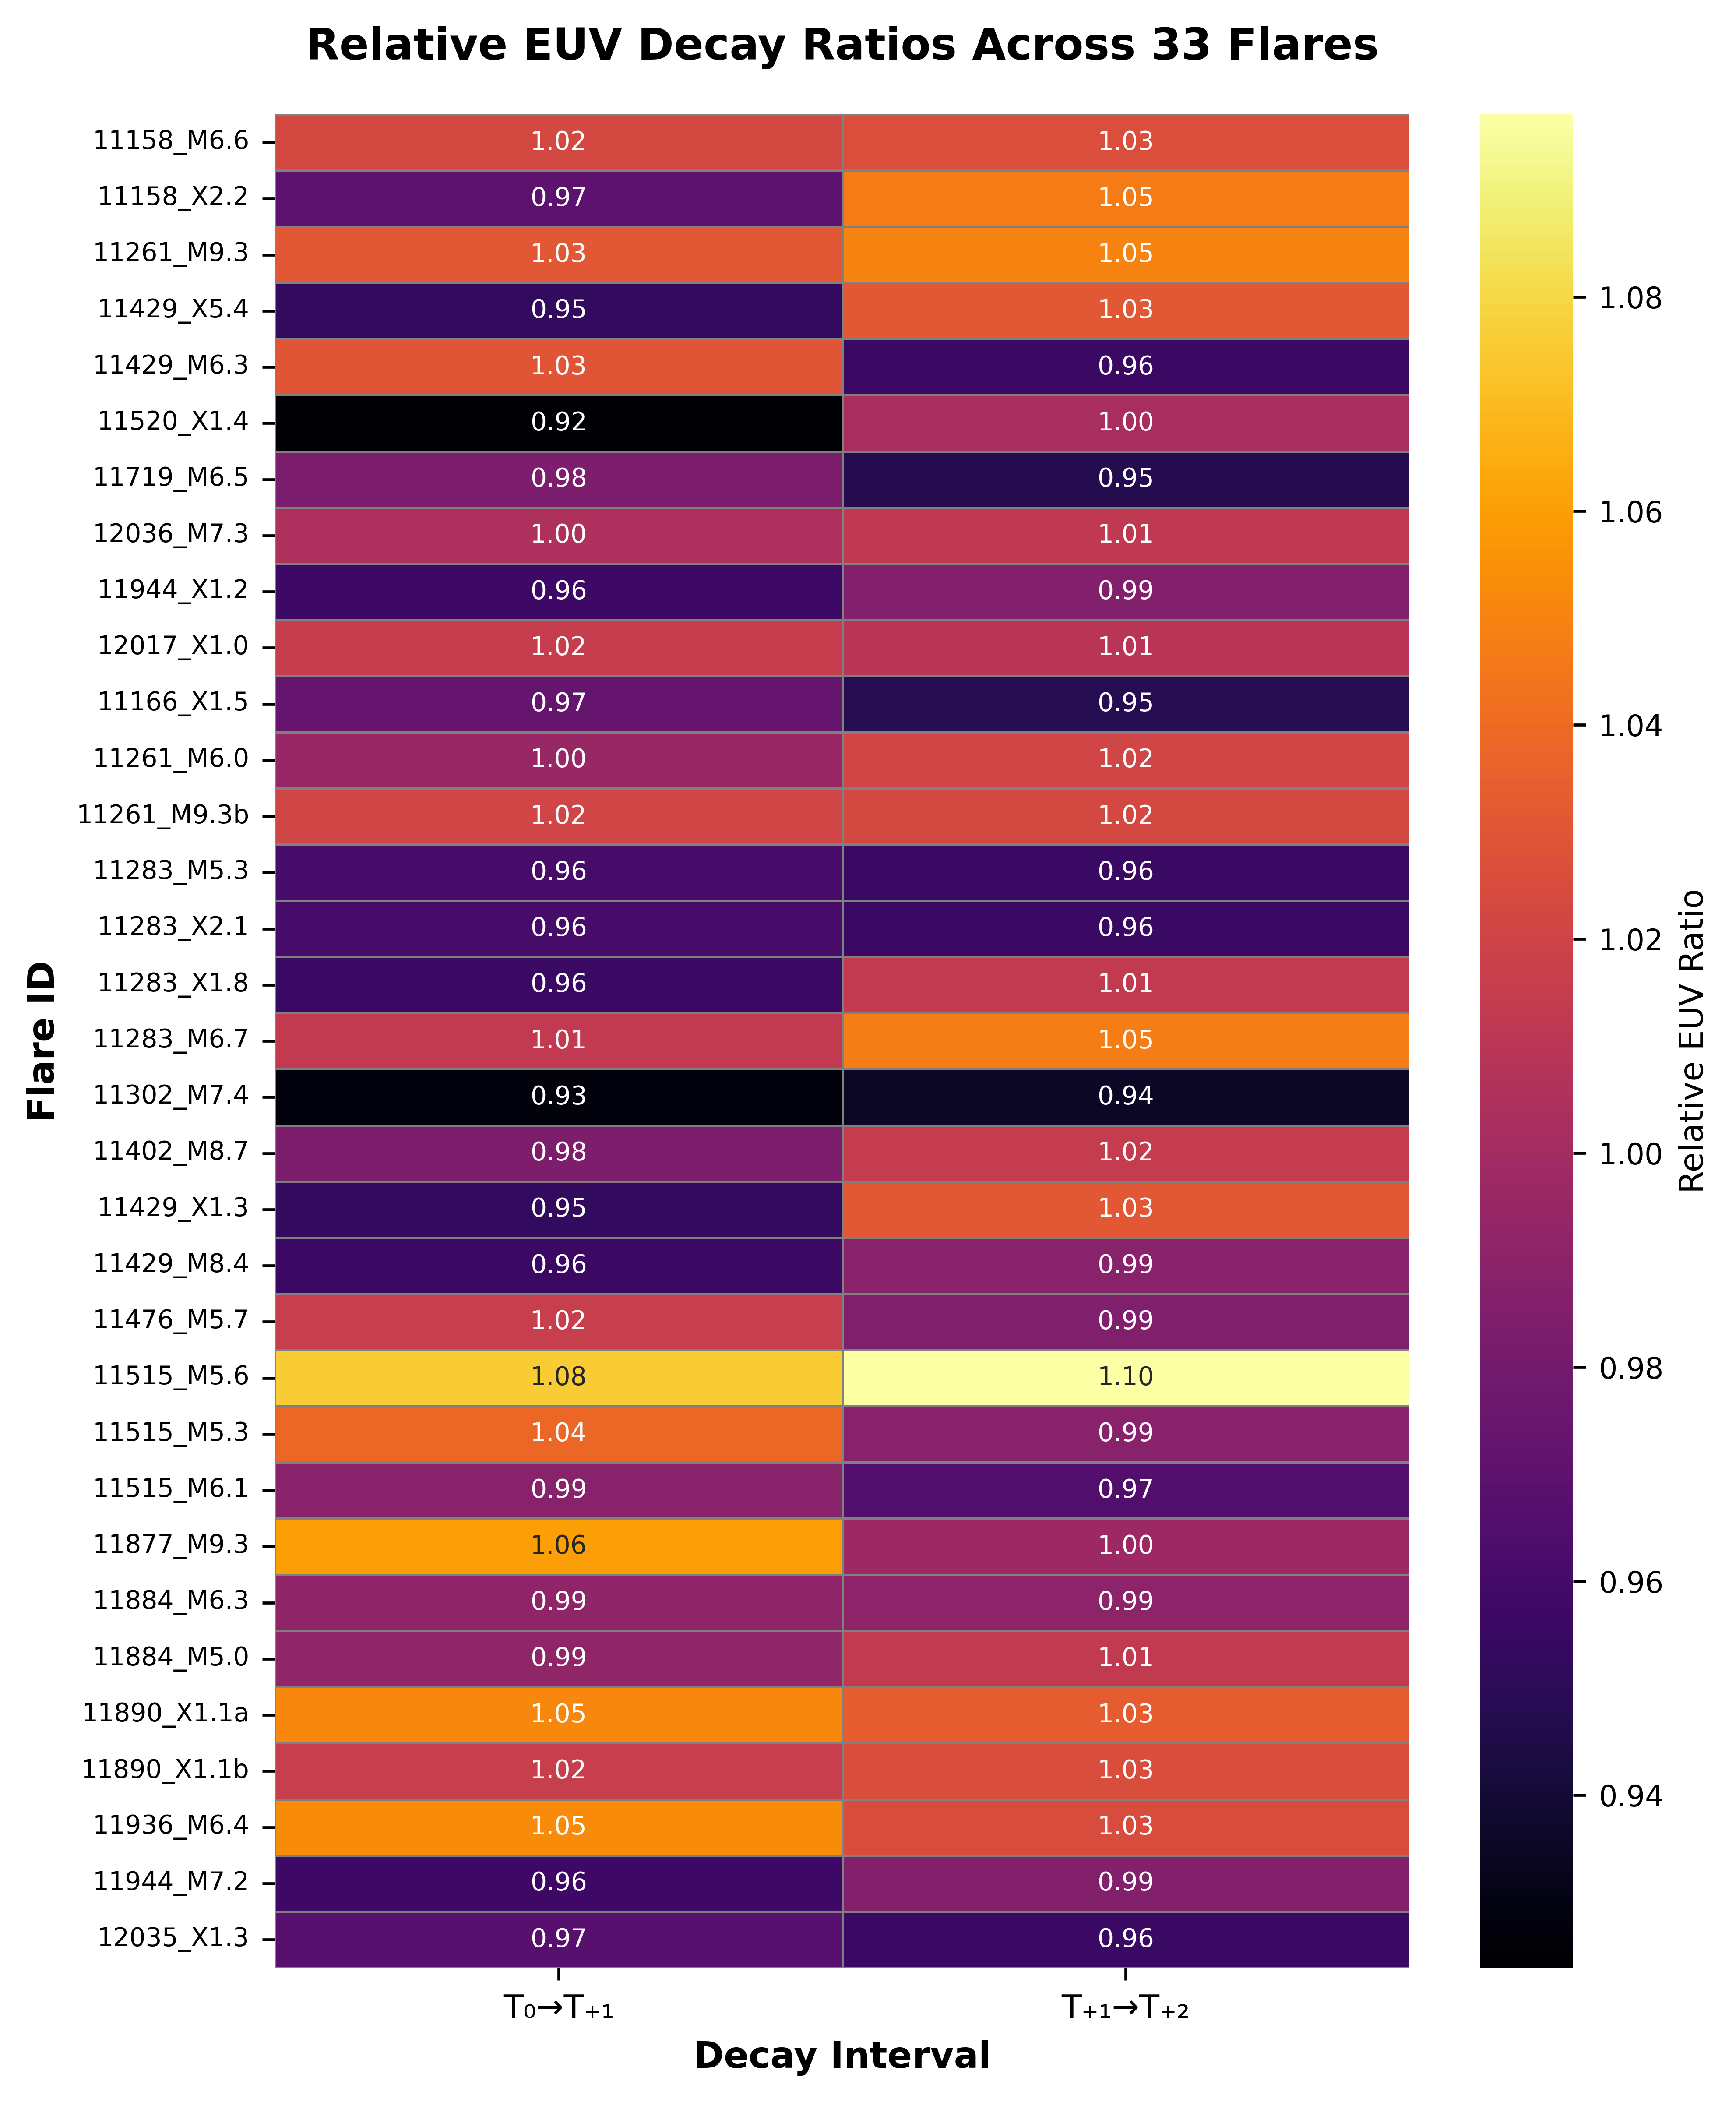


DECAY RATIO STATISTICS

T₀→T₊₁ Ratio:
  Mean:   0.994
  Median: 0.991
  Std:    0.039
  Range:  [0.924, 1.075]

T₊₁→T₊₂ Ratio:
  Mean:   1.002
  Median: 1.009
  Std:    0.037
  Range:  [0.935, 1.097]

🔥 Fastest decay (T₀→T₊₁): 11520_X1.4 (0.924)
🐌 Slowest decay (T₀→T₊₁): 11515_M5.6 (1.075)



In [9]:
# %%
# ============================================================
# ☀️ FIG. 4 — Relative Decay Ratio Heatmap (IEEE Style)
# ============================================================
# • Removes "AR" prefix
# • Matches styling of per-flare horizon heatmap
# • High-quality PDF export for IEEE paper
# • Updated for 33 flares
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load data ---
df = pd.read_csv("flare_euv_targets_3day.csv")

print(f"✅ Loaded {len(df)} flares from CSV")

# --- Remove "AR" prefix for cleaner IEEE appearance ---
df["flare_id"] = df["flare_id"].str.replace("AR", "", regex=False)

# --- Compute decay ratios ---
ratios = pd.DataFrame({
    "flare_id": df.flare_id,
    "T0→T+1": df.EUV_T1 / df.EUV_T0,
    "T+1→T+2": df.EUV_T2 / df.EUV_T1
}).set_index("flare_id")

# --- Convert to numpy array for heatmap ---
data = ratios.values
flare_ids = ratios.index.tolist()

print(f"📊 Plotting decay ratios for {len(flare_ids)} flares")

# --- IEEE figure style (adjusted height for 33 flares) ---
# Height calculation: 0.25 inches per flare + margins
fig_height = max(6.0, len(flare_ids) * 0.20 + 1.5)

plt.figure(figsize=(6.7, fig_height), dpi=600)

# Create heatmap with adjusted font sizes for readability
ax = sns.heatmap(
    data,
    annot=True,
    fmt=".2f",
    cmap="inferno",
    linewidths=0.4,
    linecolor="gray",
    xticklabels=["T₀→T₊₁", "T₊₁→T₊₂"],
    yticklabels=flare_ids,
    cbar_kws={'label': "Relative EUV Ratio"},
    annot_kws={'fontsize': 7}  # Smaller annotation for 33 flares
)

# Adjust y-tick label size for readability
ax.set_yticklabels(ax.get_yticklabels(), fontsize=7, rotation=0)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=9)

plt.title("Relative EUV Decay Ratios Across 33 Flares", 
         fontsize=12, fontweight="bold", pad=15)
plt.ylabel("Flare ID", fontsize=10, fontweight="semibold")
plt.xlabel("Decay Interval", fontsize=10, fontweight="semibold")

# Adjust colorbar
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=8)
cbar.set_label("Relative EUV Ratio", fontsize=9)

plt.tight_layout()

# --- Save high-resolution outputs ---
plt.savefig("figures/12fig_relative_decay_heatmap.pdf", dpi=600, bbox_inches="tight")
plt.savefig("figures/12fig_relative_decay_heatmap.png", dpi=600, bbox_inches="tight")

print("✅ Saved: figures/12fig_relative_decay_heatmap.pdf")
print("✅ Saved: figures/12fig_relative_decay_heatmap.png")

plt.show()

# --- Statistics summary ---
print("\n" + "="*70)
print("DECAY RATIO STATISTICS")
print("="*70)

print(f"\nT₀→T₊₁ Ratio:")
print(f"  Mean:   {ratios['T0→T+1'].mean():.3f}")
print(f"  Median: {ratios['T0→T+1'].median():.3f}")
print(f"  Std:    {ratios['T0→T+1'].std():.3f}")
print(f"  Range:  [{ratios['T0→T+1'].min():.3f}, {ratios['T0→T+1'].max():.3f}]")

print(f"\nT₊₁→T₊₂ Ratio:")
print(f"  Mean:   {ratios['T+1→T+2'].mean():.3f}")
print(f"  Median: {ratios['T+1→T+2'].median():.3f}")
print(f"  Std:    {ratios['T+1→T+2'].std():.3f}")
print(f"  Range:  [{ratios['T+1→T+2'].min():.3f}, {ratios['T+1→T+2'].max():.3f}]")

# Identify fastest/slowest decay
fastest_t0t1 = ratios['T0→T+1'].idxmin()
slowest_t0t1 = ratios['T0→T+1'].idxmax()

print(f"\n🔥 Fastest decay (T₀→T₊₁): {fastest_t0t1} ({ratios.loc[fastest_t0t1, 'T0→T+1']:.3f})")
print(f"🐌 Slowest decay (T₀→T₊₁): {slowest_t0t1} ({ratios.loc[slowest_t0t1, 'T0→T+1']:.3f})")

print("\n" + "="*70)